In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the CSV file
data_path = "../data/storm_data/"
file_name = 'filtered_storm_data_CA_2024.csv'
data = pd.read_csv(data_path + file_name)

# Display the first few rows to understand the structure
# print(data.head())

In [ ]:
# Check the column names and their data types
# print(data.info())

In [3]:
# Define the relevant weather events
relevant_events = ["Lightning", "High Wind", "Strong Wind", "Thunderstorm Wind", "Tornado"]


In [4]:
# Filter the data for relevant events
filtered_data = data[data['EVENT_TYPE'].isin(relevant_events)]

# Display the first few rows of the filtered data
#print(filtered_data.head())

## EDA

In [5]:
# Summary statistics of the relevant columns
filtered_data[['MAGNITUDE', 'INJURIES_DIRECT', 'DEATHS_DIRECT']].describe()

,MAGNITUDE,INJURIES_DIRECT,DEATHS_DIRECT
count,643.000000,653.000000,653.000000
mean,55.502333,0.010720,0.007657
std,16.191261,0.179147,0.117239
min,17.000000,0.000000,0.000000
25%,50.000000,0.000000,0.000000
50%,54.000000,0.000000,0.000000
75%,61.000000,0.000000,0.000000
max,134.000000,4.000000,2.000000


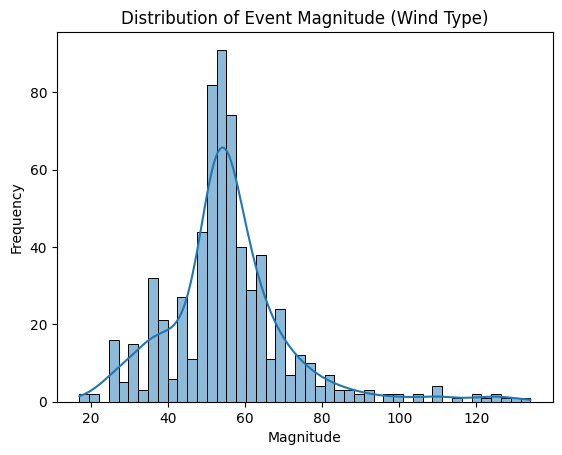

In [6]:
# Distribution of MAGNITUDE for Wind Type
sns.histplot(filtered_data['MAGNITUDE'], kde=True)
plt.title('Distribution of Event Magnitude (Wind Type)')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.show()

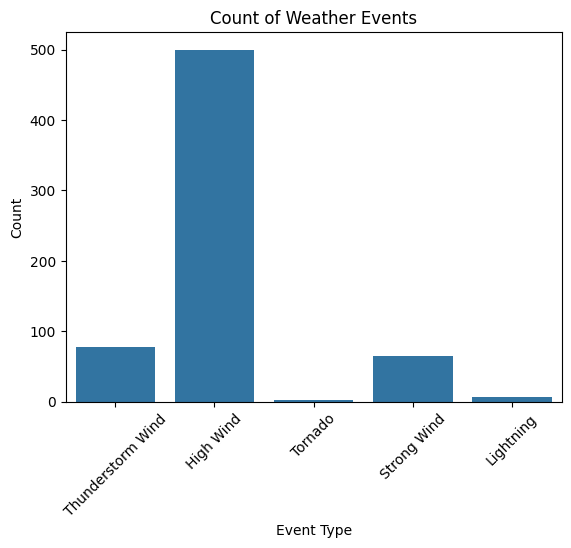

In [7]:
# Count plot for different event types
sns.countplot(x='EVENT_TYPE', data=filtered_data)
plt.title('Count of Weather Events')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [9]:
# Convert BEGIN_DATE_TIME to datetime format
filtered_data['BEGIN_DATE_TIME'] = pd.to_datetime(filtered_data['BEGIN_DATE_TIME'], format='%d-%b-%y %H:%M:%S')

# Extract Year and Month from BEGIN_DATE_TIME
filtered_data['BEGIN_MONTH'] = filtered_data['BEGIN_DATE_TIME'].dt.to_period('M')
# Check the conversion
#print(filtered_data[['BEGIN_DATE_TIME']].head())

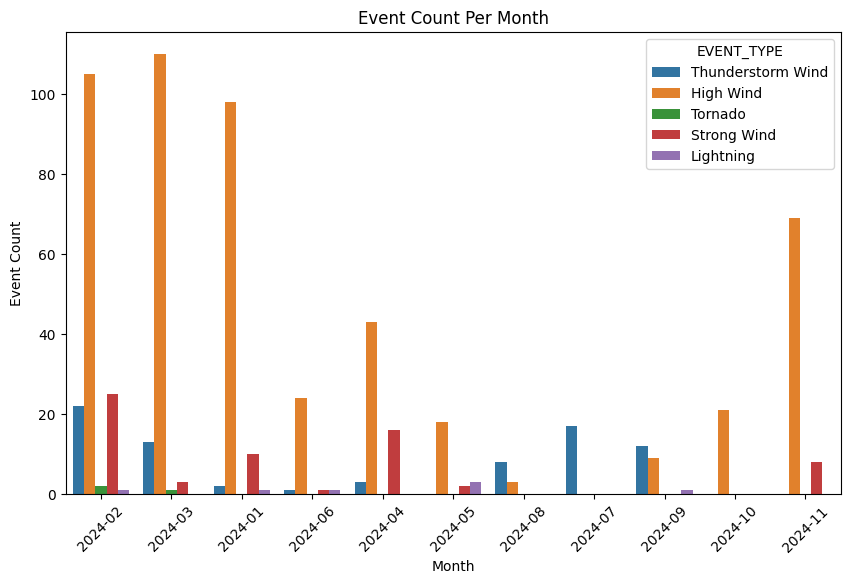

In [10]:
# Plot the event counts per month
plt.figure(figsize=(10, 6))
sns.countplot(x='BEGIN_MONTH', data=filtered_data, hue='EVENT_TYPE')
plt.title('Event Count Per Month')
plt.xlabel('Month')
plt.ylabel('Event Count')
plt.xticks(rotation=45)
plt.show()

            Location  Event Count
0             PERRIS            8
1          MONTECITO            3
2            VINCENT            3
3        WARNER SPGS            2
4               LANG            2
5       BUCKMAN SPGS            2
6  (EED)NEEDLES ARPT            2
7   WHISPERING PINES            2
8         (CZZ)CAMPO            2
9            BARSTOW            2


/tmp/ipykernel_15777/3384835311.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Event Count', y='Location', data=location_counts.head(10), palette='Set2')


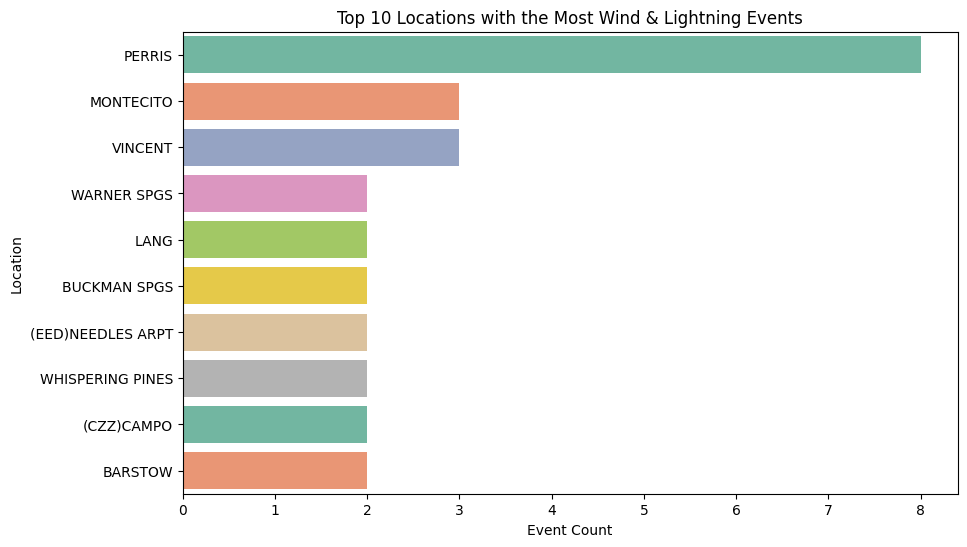

In [13]:
# Group by BEGIN_LOCATION and count the number of events for each location
location_counts = filtered_data['BEGIN_LOCATION'].value_counts().reset_index()
location_counts.columns = ['Location', 'Event Count']

# Display the top 10 locations with the most events
print(location_counts.head(10))

# Plot the top 10 locations with the most events
plt.figure(figsize=(10, 6))
sns.barplot(x='Event Count', y='Location', data=location_counts.head(10), palette='Set2')
plt.title('Top 10 Locations with the Most Wind & Lightning Events')
plt.xlabel('Event Count')
plt.ylabel('Location')
plt.show()


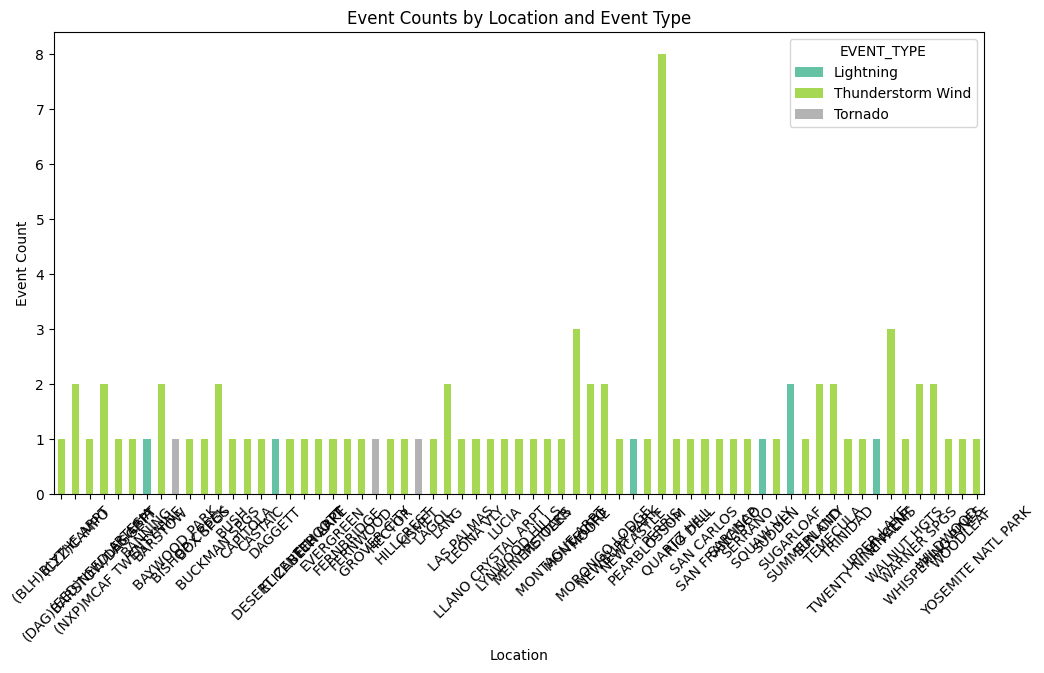

In [15]:
# Event Counts by Location and Event Type (Stacked Bar Plot)
location_event_counts = pd.crosstab(filtered_data['BEGIN_LOCATION'], filtered_data['EVENT_TYPE'])

# Plotting stacked bar plot
location_event_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Event Counts by Location and Event Type')
plt.xlabel('Location')
plt.ylabel('Event Count')
plt.xticks(rotation=45)
plt.show()
